## 1.Perkenalan Dataset

Proyek ini menggunakan **Diabetes Dataset** dari Scikit-Learn.

**Tujuan:**
- Memuat dataset mentah
- Melakukan Exploratory Data Analysis (EDA).
- Melakukan preprocessing data agar siap digunakan untuk training model machine learning
- Target: `target` (progresi penyakit diabetes 1 tahun setelah baseline)

## 2. Import Library

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import library utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scikit-Learn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

# Konfigurasi visualisasi
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")
%matplotlib inline

print("Library berhasil diimport.")

Library berhasil diimport.


## 3. Memuat Dataset

Memuat dataset Diabetes dari Scikit-Learn.

In [2]:
# Load dataset dari sklearn
diabetes = load_diabetes()

# Konversi ke DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

# Tampilkan informasi dataset
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"Nama kolom: {list(df.columns)}")
print(f'Tipe data:\n{df.dtypes}')

Jumlah baris: 442
Jumlah kolom: 11
Nama kolom: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']
Tipe data:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object


## 4.Exploratory Data Analysis (EDA)

Melakukan eksplorasi data untuk memahami karakteristik dataset.

### 4.1 Informasi Dataset

In [3]:
# Tampilkan info dataset
print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
df.info()

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


### 4.2 Statistik Deskriptif

In [4]:
# Tampilkan statistik deskriptif
print("=" * 50)
print("STATISTIK DESKRIPTIF")
print("=" * 50)
df.describe()

STATISTIK DESKRIPTIF


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


### 4.3 Pengecekan Missing Values

In [5]:
# Cek missing values
print("=" * 50)
print("CEK MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({"Jumlah Missing": missing, "Persentase (%)": missing_pct})
print(missing_df[missing_df["Jumlah Missing"] > 0] if missing.sum() > 0 else "Tidak ada missing values.")

CEK MISSING VALUES
Tidak ada missing values.


### 4.4 Distribusi Data

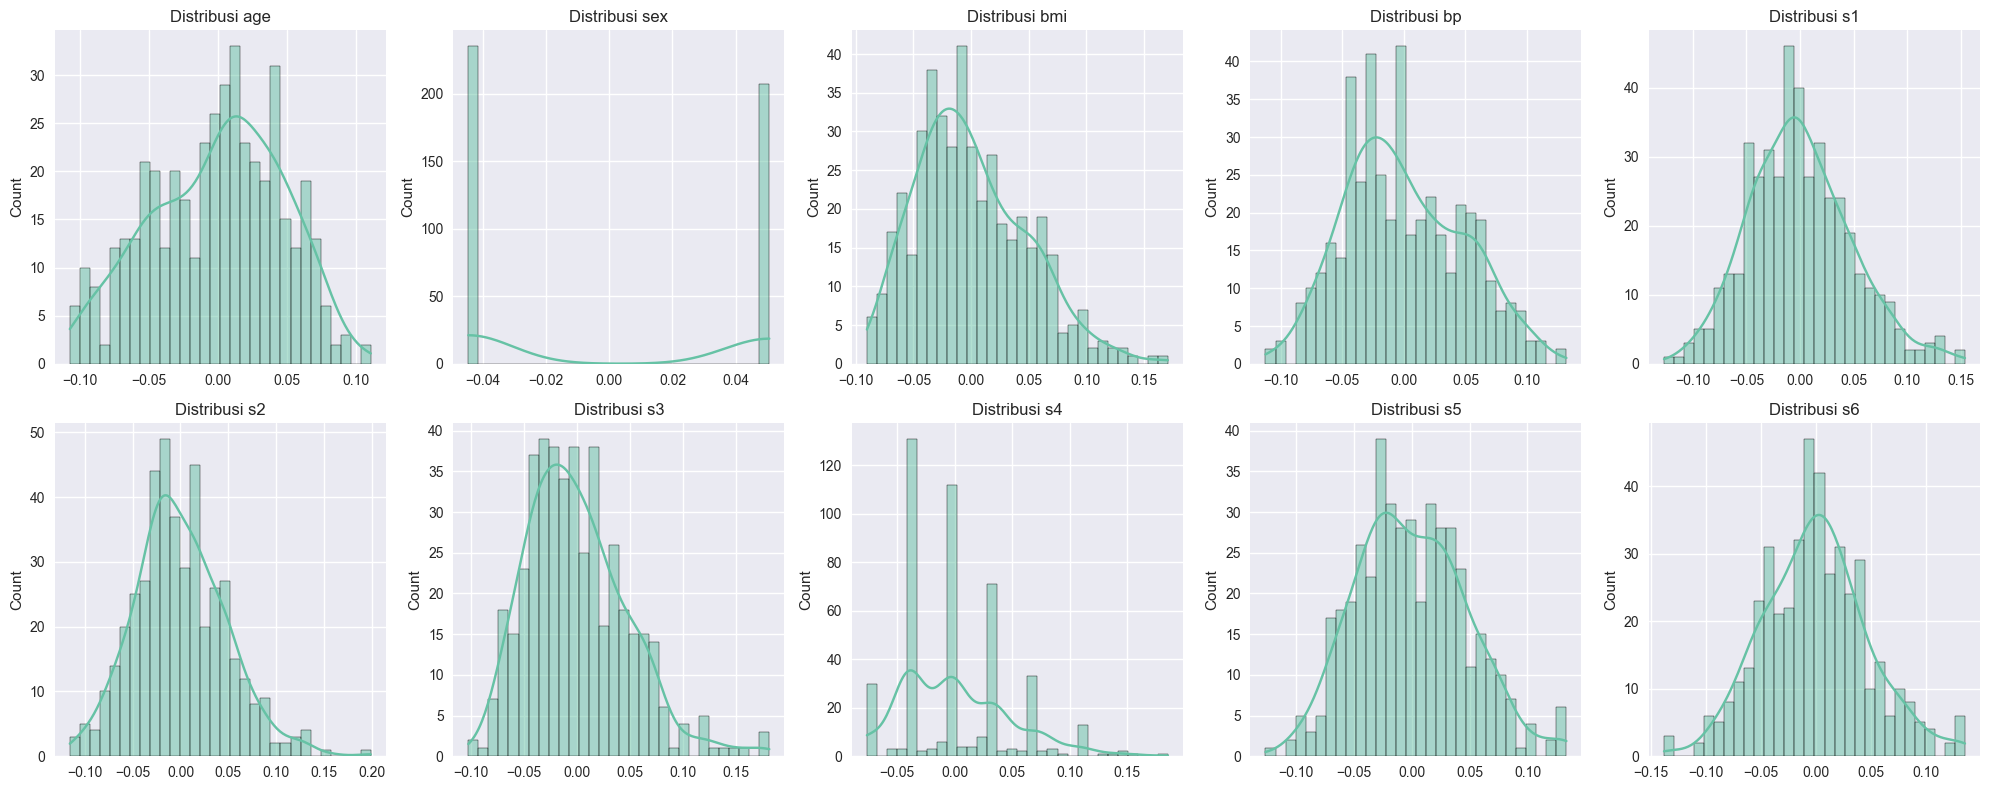

In [6]:
# Visualisasi distribusi data
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(diabetes.feature_names):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f"Distribusi {col}", fontsize=12)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

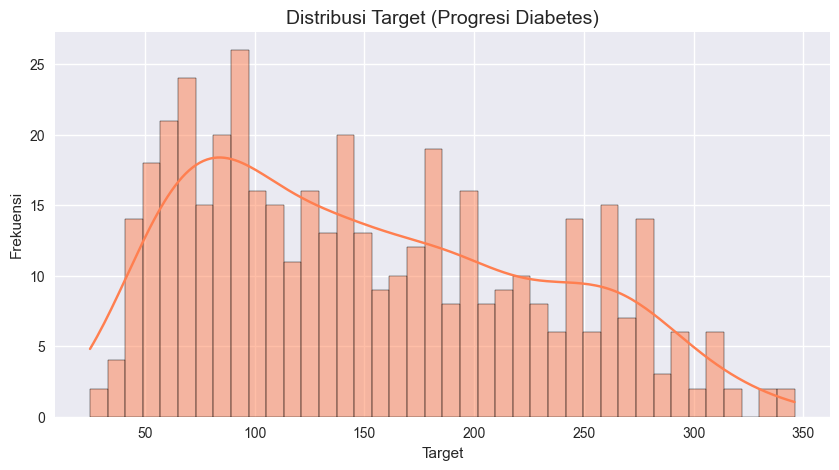

In [7]:
# Visualisasi distribusi target
plt.figure(figsize=(10, 5))
sns.histplot(df["target"], kde=True, bins=40, color="coral")
plt.title("Distribusi Target (Progresi Diabetes)", fontsize=14)
plt.xlabel("Target")
plt.ylabel("Frekuensi")
plt.show()

### 4.5 Korelasi Fitur

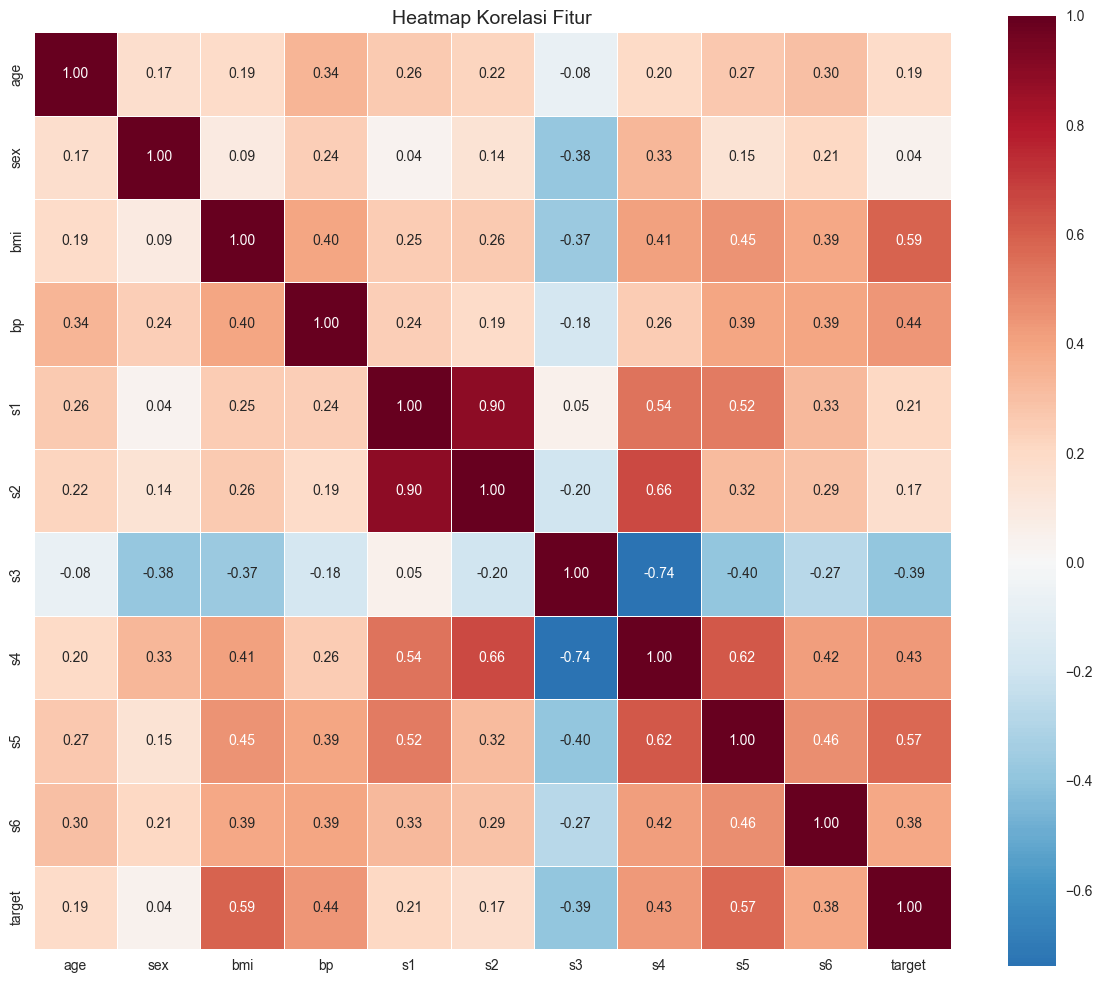

In [8]:
# Hitung matriks korelasi
corr_matrix = df.corr()

# Visualisasi heatmap korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, fmt=".2f",
            linewidths=0.5, square=True)
plt.title("Heatmap Korelasi Fitur", fontsize=14)
plt.tight_layout()
plt.show()

KORELASI FITUR DENGAN TARGET
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


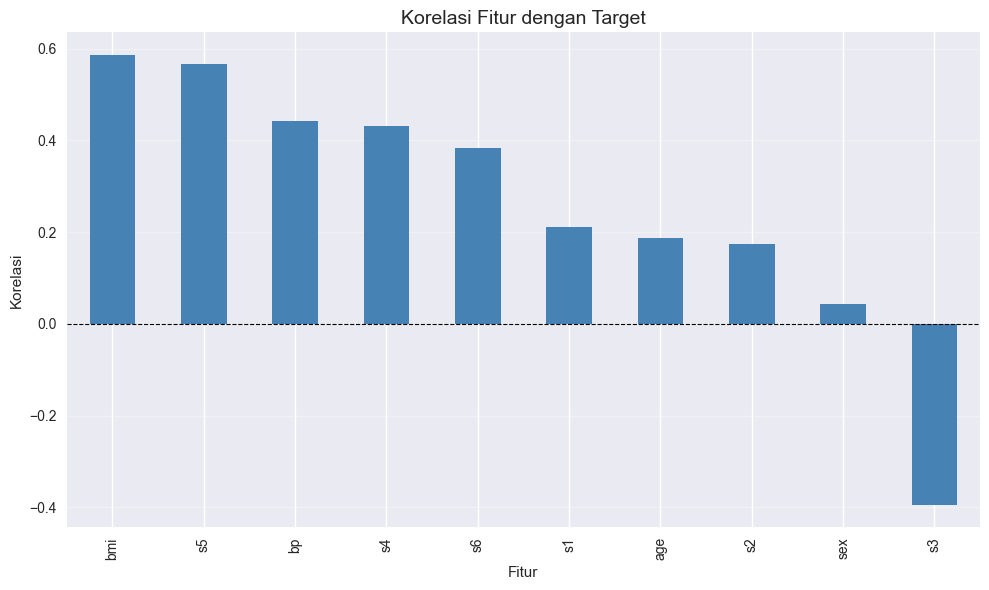

In [9]:
# Korelasi fitur dengan target
print("=" * 50)
print("KORELASI FITUR DENGAN TARGET")
print("=" * 50)
target_corr = corr_matrix["target"].drop("target").sort_values(ascending=False)
print(target_corr)

# Visualisasi korelasi dengan target
plt.figure(figsize=(10, 6))
target_corr.plot(kind="bar", color="steelblue")
plt.title("Korelasi Fitur dengan Target", fontsize=14)
plt.xlabel("Fitur")
plt.ylabel("Korelasi")
plt.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 4.6 Visualisasi Pairplot

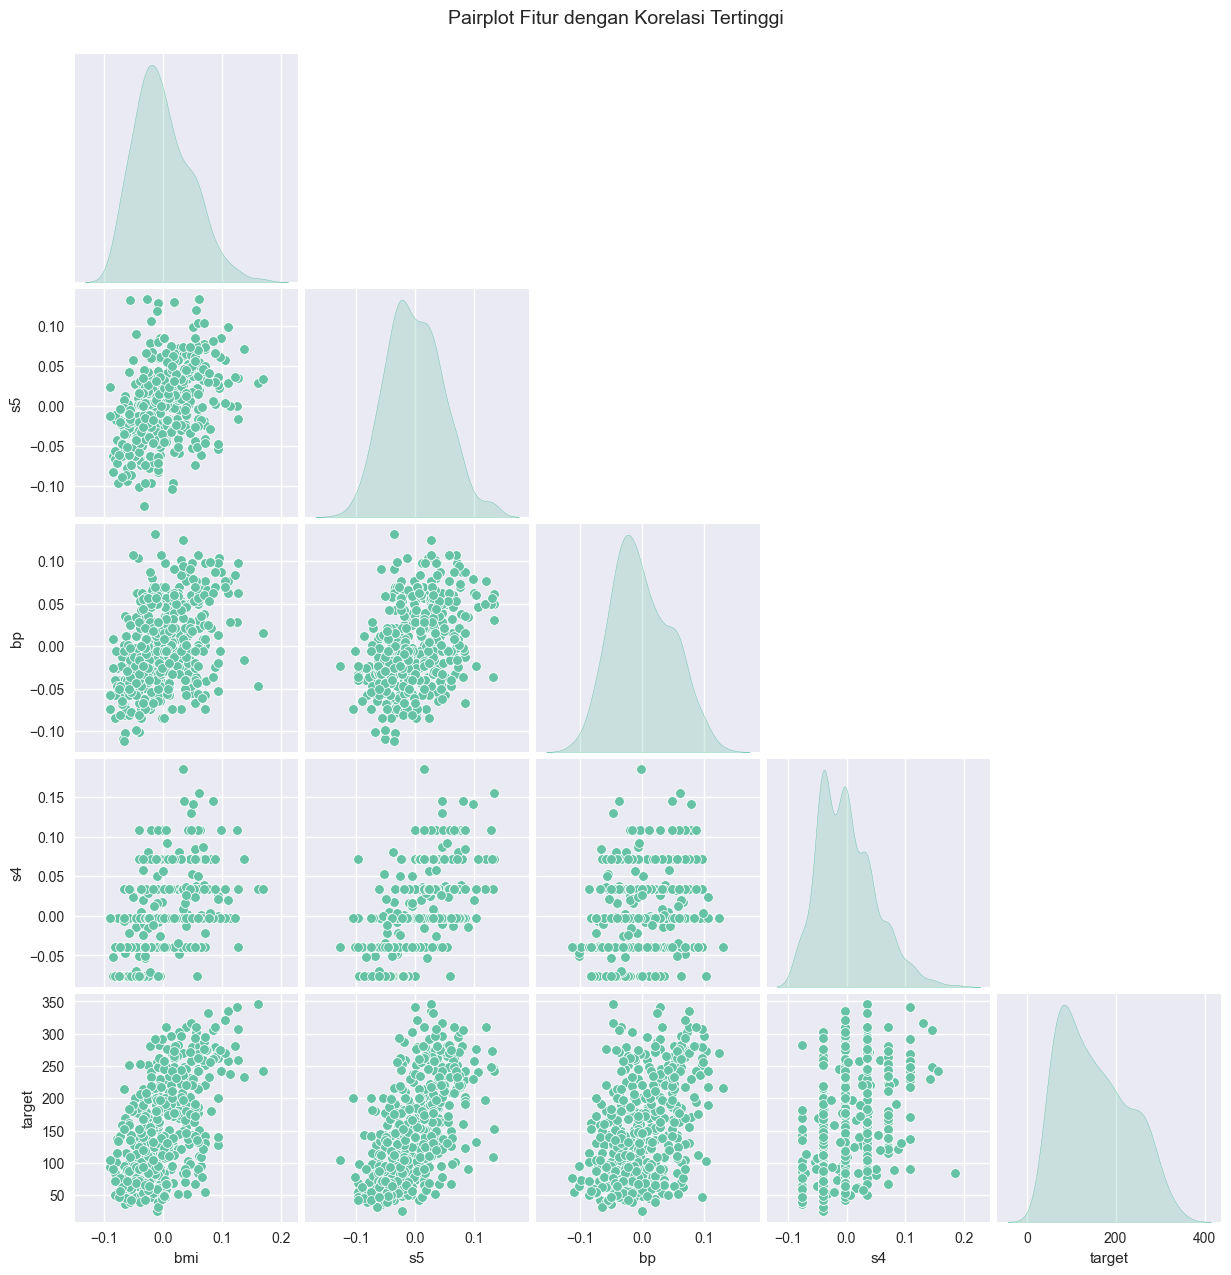

In [10]:
# Pairplot untuk fitur dengan korelasi tertinggi
top_features = target_corr.abs().nlargest(4).index.tolist()
top_features.append("target")

sns.pairplot(df[top_features], diag_kind="kde", corner=True)
plt.suptitle("Pairplot Fitur dengan Korelasi Tertinggi", y=1.02, fontsize=14)
plt.show()

## 5. Preprocessing

Melakukan tahapan preprocessing data.

### 5.1 Handling Missing Values

Dataset Diabetes dari sklearn sudah bersih (tidak ada missing values). Namun tetap dilakukan pengecekan dan penanganan untuk jaga-jaga.

In [11]:
# Handling missing values (jika ada)
if df.isnull().sum().sum() > 0:
    # Isi missing values dengan median untuk kolom numerik
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"Kolom {col}: diisi dengan median {median_val:.4f}")
else:
    print("Tidak ada missing values. Data sudah bersih.")

# Konfirmasi tidak ada missing values
print(f"Total missing values setelah handling: {df.isnull().sum().sum()}")

Tidak ada missing values. Data sudah bersih.
Total missing values setelah handling: 0


### 5.2 Pengecekan Outlier

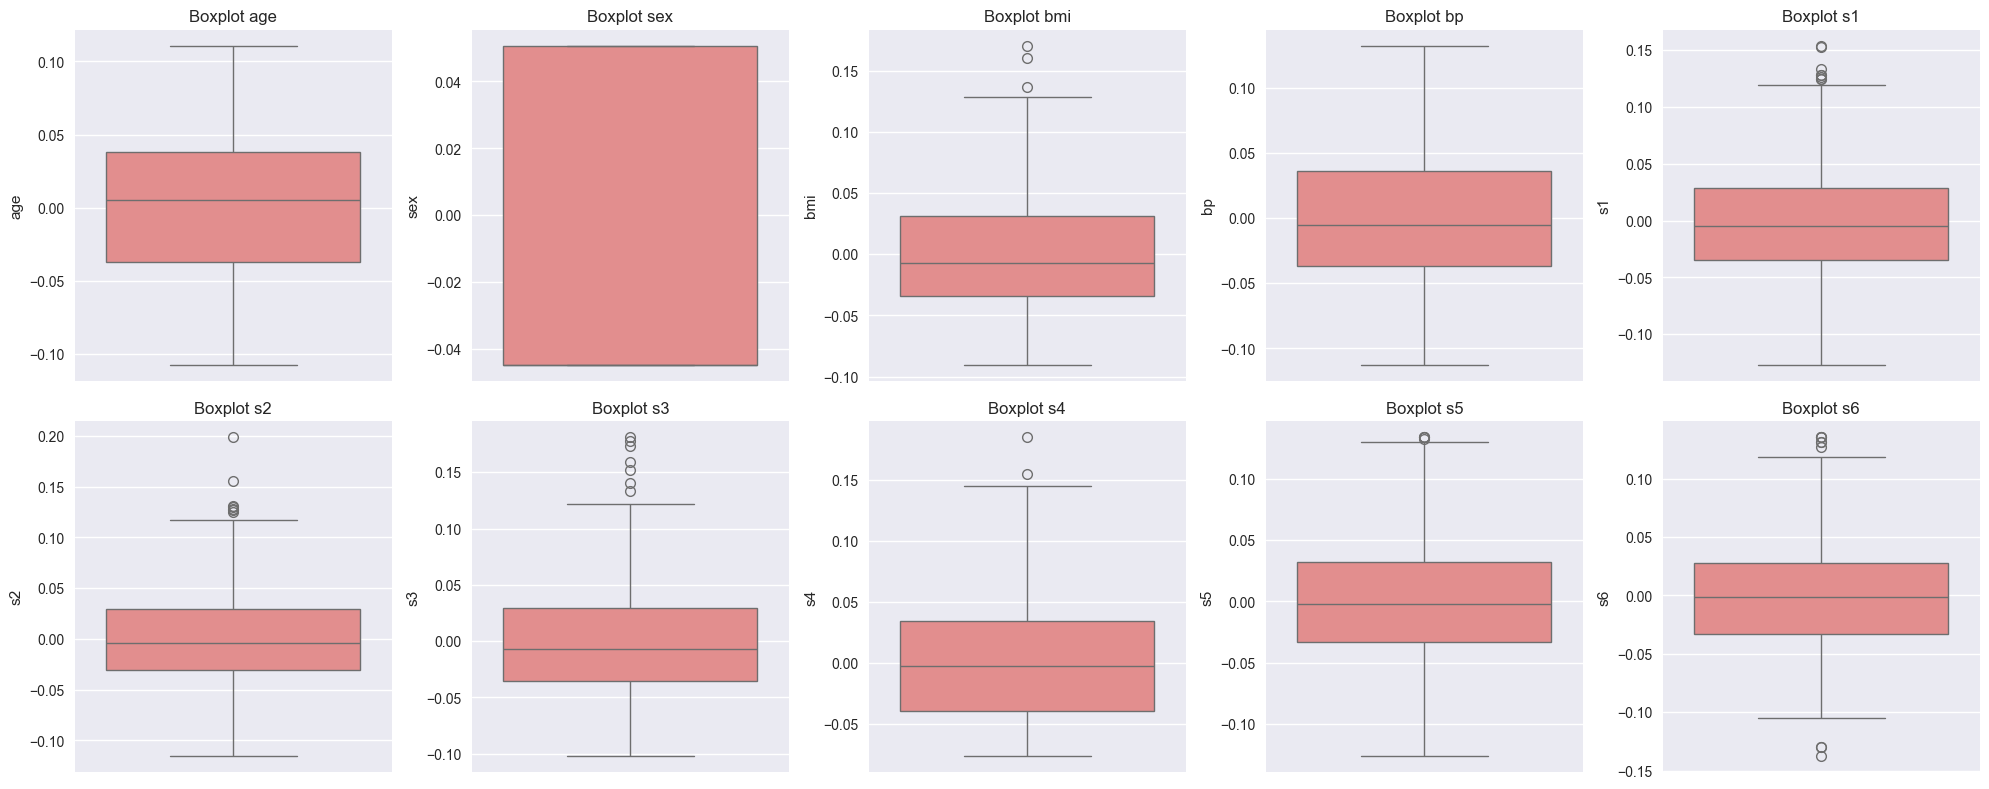

In [12]:
# Visualisasi boxplot untuk deteksi outlier
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(diabetes.feature_names):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot {col}", fontsize=12)

plt.tight_layout()
plt.show()

### 5.3 Feature Selection

Memilih fitur yang memiliki korelasi signifikan dengan target menggunakan SelectKBest.

In [13]:
# Feature selection menggunakan SelectKBest dengan f_regression
X = df[diabetes.feature_names]
y = df["target"]

# Pilih 8 fitur terbaik (dari 10 fitur)
selector = SelectKBest(score_func=f_regression, k=8)
X_selected = selector.fit_transform(X, y)

# Tampilkan skor fitur
feature_scores = pd.DataFrame({
    "Fitur": diabetes.feature_names,
    "Skor": selector.scores_
}).sort_values("Skor", ascending=False)

print("SKOR FITUR (SelectKBest):")
print("=" * 50)
print(feature_scores)

# Fitur yang terpilih
selected_features = np.array(diabetes.feature_names)[selector.get_support()]
print(f"Fitur terpilih ({len(selected_features)}): {list(selected_features)}")

SKOR FITUR (SelectKBest):
  Fitur        Skor
2   bmi  230.653764
8    s5  207.271194
3    bp  106.520131
7    s4  100.069264
6    s3   81.239659
9    s6   75.399683
4    s1   20.710567
0   age   16.101374
5    s2   13.746079
1   sex    0.817423
Fitur terpilih (8): ['age', 'bmi', 'bp', 's1', 's3', 's4', 's5', 's6']


### 5.4 Train-Test Split

Membagi data menjadi data training dan testing.

In [14]:
# Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features], y,
    test_size=0.2,
    random_state=42
)

print(f"Ukuran training set: {X_train.shape}")
print(f"Ukuran testing set: {X_test.shape}")
print(f"Ukuran target training: {y_train.shape}")
print(f"Ukuran target testing: {y_test.shape}")

Ukuran training set: (353, 8)
Ukuran testing set: (89, 8)
Ukuran target training: (353,)
Ukuran target testing: (89,)


### 5.5 Normalisasi / Scaling

Dataset Diabetes sudah discaling oleh sklearn (mean=0, std=1). Namun kita demonstrasikan StandardScaler untuk konsistensi.

In [15]:
# StandardScaler untuk normalisasi
scaler = StandardScaler()

# Fit dan transform training set
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing set
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features)

# Tampilkan hasil scaling
print("Statistik data setelah scaling (training set):")
print("=" * 50)
print(X_train_scaled.describe().round(4))

# Gabungkan fitur dan target untuk dataset akhir
df_train = X_train_scaled.copy()
df_train["target"] = y_train.values

df_test = X_test_scaled.copy()
df_test["target"] = y_test.values

# Gabungkan semua data
df_preprocessing = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)
print(f"Dataset preprocessing akhir: {df_preprocessing.shape}")

Statistik data setelah scaling (training set):
            age       bmi        bp        s1        s3        s4        s5  \
count  353.0000  353.0000  353.0000  353.0000  353.0000  353.0000  353.0000   
mean     0.0000   -0.0000    0.0000   -0.0000    0.0000    0.0000    0.0000   
std      1.0014    1.0014    1.0014    1.0014    1.0014    1.0014    1.0014   
min     -2.3486   -1.9262   -2.3467   -2.2704   -2.1568   -1.6087   -2.6657   
25%     -0.6999   -0.7162   -0.7817   -0.7421   -0.6677   -0.8355   -0.7216   
50%      0.1637   -0.1454   -0.1415   -0.0789   -0.1191   -0.0622   -0.0383   
75%      0.7918    0.6537    0.7121    0.5555    0.5862    0.7110    0.6792   
max      2.3620    3.3706    2.7038    3.2371    3.8778    3.8736    2.7718   

             s6  
count  353.0000  
mean    -0.0000  
std      1.0014  
min     -2.8908  
25%     -0.6616  
50%      0.0243  
75%      0.6244  
max      2.7679  
Dataset preprocessing akhir: (442, 9)


### 5.6 Simpan Dataset Preprocessing

Menyimpan dataset hasil preprocessing ke file CSV.

In [17]:
# Simpan dataset hasil preprocessing
output_path = "dataset_preprocessing.csv"
df_preprocessing.to_csv(output_path, index=False)
print(f"Dataset preprocessing berhasil disimpan ke: {output_path}")
print(f"Total {df_preprocessing.shape[0]} baris, {df_preprocessing.shape[1]} kolom")
print(f"Kolom: {list(df_preprocessing.columns)}")

Dataset preprocessing berhasil disimpan ke: dataset_preprocessing.csv
Total 442 baris, 9 kolom
Kolom: ['age', 'bmi', 'bp', 's1', 's3', 's4', 's5', 's6', 'target']


### 5.7 Kesimpulan

**Ringkasan tahapan preprocessing yang telah dilakukan:**

1. **Data Loading** - Memuat Diabetes dataset dari Scikit-Learn (442 sampel, 10 fitur)
2. **EDA** - Melakukan eksplorasi data: info, statistik deskriptif, missing values, distribusi, korelasi, visualisasi
3. **Handling Missing Values** - Dataset sudah bersih (tidak ada missing values)
4. **Feature Selection** - Memilih 8 fitur terbaik menggunakan SelectKBest dengan f_regression
5. **Train-Test Split** - Membagi data 80% training dan 20% testing
6. **Scaling** - StandardScaler untuk normalisasi fitur
7. **Save Data** - Dataset hasil preprocessing disimpan sebagai dataset_preprocessing.csv

**Insight penting:**
- Kolom `bmi` dan `s5` memiliki korelasi tertinggi dengan target
- Fitur `s1` dan `s6` memiliki korelasi terendah, dapat dipertimbangkan untuk tidak digunakan